# Example 4 — Mission Phase Transition and Attitude Control

This example demonstrates a multi-phase mission. The spacecraft begins in a translational phase and transitions to a phase containing guidance, navigation, attitude control, RCS actuation, and high-rate rotational/translational propagation.

### Notes and repository setup

Initial imports and repository path configuration used by the example.

In [51]:
import numpy as np
from pathlib import Path
import sys

path = Path.cwd()

REPO_ROOT = path.parents[1]

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## General Simulation Setup

We start the simulation setup similarly to the previous examples.

### Environment

The environment object provides the simulation environment in which the spacecraft dynamics are evaluated.

In [52]:
# Define the environment
from py.modules.enviroments.environments import ClassicalEnvironment

env = ClassicalEnvironment() # NOTE: Need to review for proper implmentation of the environment class

### Simulation setup

The `Simulation` object defines the overall simulation horizon and environment. This works as a central orchestrator for each spacecraft that will be added to the sim.

*Note: All the units in the simulations are in the International Metric System.*

In [53]:
from py.modules.new.simulation import Simulation

sim_max_time = 60*15

sim = Simulation(max_sim_time=sim_max_time,
                 environment= env,
                 verbose = True
)

## Spacecraft Creation

We will begin by creating a spacecraft similar to the first example, with thrusters, but with two absolute sensors, each with a different refresh time, so each phase can use a different one.

In [54]:
from py.modules.sensors.generic_sensor import AbsoluteSensor

# Update times

dt_phase_1 = 20.0  # Propagation update every 20 seconds
dt_phase_2 = 10.0  # Propagation update every 10 seconds

sensors = [AbsoluteSensor(100), AbsoluteSensor(100, verbose=False)]

In [55]:
from py.modules.actuators.RCS import RCSThruster

thruster_X_pos = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_X_neg = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([-1, 0, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
    
)

thruster_Y_pos = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([0, 1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Y_neg = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([0, -1, 0]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thruster_Z_pos = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([0, 0, 1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0   
)

thruster_Z_neg = RCSThruster(
    nominal_thrust=0.01,
    direction= np.array([0, 0, -1]),
    override_torque_value = 300,
    modulation_window= 0.1,
    minimum_on_time= 0.01,
    activation_threshold= 0.0
)

thrusters = [thruster_X_pos, thruster_X_neg, thruster_Y_pos, thruster_Y_neg, thruster_Z_pos, thruster_Z_neg]

We will now begin to model the first phase of the mission, which will be similar to the one in Example 2.

In [56]:
from py.modules.navigation.basic_laws import IdealNavigation

nav_law = IdealNavigation()

from py.modules.propagators.native_propagator import NativeTranslationalPropagator
translational_propagator = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")

from py.general.dataclasses import MissionPhase

initial_phase = MissionPhase(
    name="Initial Phase",
    navigation=nav_law,
    dt_nav=dt_phase_1,
    dt_propagation=dt_phase_1,
    translational_model=translational_propagator
)

Now we will model the second phase, which will combine both translational and rotational movement, with an attitude controller.

As mentioned previously, note that we have two absolute sensors. As we want to use the second absolute sensor in this phase, we can pass that to the ideal navigation law.

In [57]:
translational_propagator_phase_2 = NativeTranslationalPropagator(dynamics="REL2BP", integration_method="NATIVE_RK45")

from py.modules.propagators.native_propagator import NativeRotationalPropagator
rotational_propagator_phase_2 =  NativeRotationalPropagator(integration_method="NATIVE_RK45")


nav_law_phase_2 = IdealNavigation(sensor_to_be_use=2)  # Use the second AbsoluteSensor for phase 2

from py.modules.guidance.basic_laws import ConstantReferenceGuidance
from py.modules.math import quaternion_from_euler
objective_orientation = [0, 0, 0]  # Desired orientation in Euler angles (degrees)
guidance_law = ConstantReferenceGuidance(
    desired_quat = quaternion_from_euler(np.deg2rad(objective_orientation[0]), np.deg2rad(objective_orientation[1]), np.deg2rad(objective_orientation[2]))
)

from py.modules.controllers.classic_controllers import PDAttitudeController

control_law = PDAttitudeController(
    proportional_gain= 1000,    
    derivative_gain= 20000,
    maximum_torque= 1000,
    minimum_torque= -1000
)

from py.modules.controllers.basic_laws import BasicRCSAllocator
allocator_law = BasicRCSAllocator()


second_phase = MissionPhase(
    name="Second Phase",

    guidance= guidance_law,
    navigation=nav_law_phase_2,
    controller= control_law,

    allocator = allocator_law,


    dt_nav=0.1, # Navigation update every 0.1 seconds
    dt_guid=1, # Guidance update every 1 second
    dt_control=0.1, # Control update every 0.1 seconds
    
    translational_model=translational_propagator_phase_2,
    rotational_model=rotational_propagator_phase_2,

    dt_propagation= 0.01
)

### Mission Manager and Transitions

We can now begin to model the mission manager and its transitions, so we begin by setting which is the initial phase and then adding the second phase.

In [58]:
from py.modules.new.mission_manager import MissionManager

mission_manager = MissionManager(
    initial_phase=initial_phase
)

mission_manager.add_phases(second_phase)


For the transition, we can have multiple transitions between the same two phases, as each transition can be triggered by different parameters, for example, when a certain amount of time has passed, or when a certain position/velocity is acquired.

In this case, we will define a single transition between phases.

That transition needs a function that will be evaluated during runtime to see if the condition is met. Therefore, any condition needs to return a bool, true if it will trigger the transition or false if not.

In [59]:

def condition_sc1_time(simulation_data) -> bool:

    for spacecraft in simulation_data.spacecrafts:

        if spacecraft.name == "SC1":
            return spacecraft.spacecraft_data.t >= (sim_max_time - (300))  # Transition after half of the simulation time

    return False

Then we can just add the transition.

In [60]:

mission_manager.add_transition(
    from_phase=initial_phase,
    target_phase=second_phase,
    condition=condition_sc1_time
)

### Creation

We can now create the spacecraft.

In [61]:
initial_position = np.array([7000e3, 0, 3500e3])  # Initial position in meters
initial_velocity = np.array([0, 7.5e3, 0])
initial_orientation = initial_orientation = [45, -30, -10]  # Initial orientation in Euler angles (degrees)
initial_orientation_quat = quaternion_from_euler(np.deg2rad(initial_orientation[0]), np.deg2rad(initial_orientation[1]), np.deg2rad(initial_orientation[2]))
initial_angular_velocity = np.array([-0.08, 0.05, 0.1])  # Initial angular velocity in rad/s

from py.general.general_data import Ix_total, Iy_total, Iz_total

inertia_tensor=np.diag([
    Ix_total,
    Iy_total,
    Iz_total
])

sim.add_spacecraft(
    name="SC1",
    initial_position=initial_position,
    initial_velocity=initial_velocity,
    initial_attitude=initial_orientation_quat,
    initial_angular_velocity=initial_angular_velocity,
    inertia_tensor= np.diag([Ix_total, Iy_total, Iz_total]),  # Inertia tensor in kg*m^2
    sensors=sensors,
    mission_manager=mission_manager,    
    actuators=thrusters,
)

Spacecraft 'SC1' added to the simulation.


## Simulation execution and results

We can now simulate and use some built-in functions to graph the results.

In [62]:
# We can now simulate
result = sim.simulate()

Initializing simulation...
Spacecraft 'SC1' dt_nav: 20.0, dt_guid: nan, dt_control: nan
Simulation initialized.
Starting simulation...
Spacecraft 'SC1' dt_nav: 0.1, dt_guid: 1, dt_control: 0.1
Simulation completed.


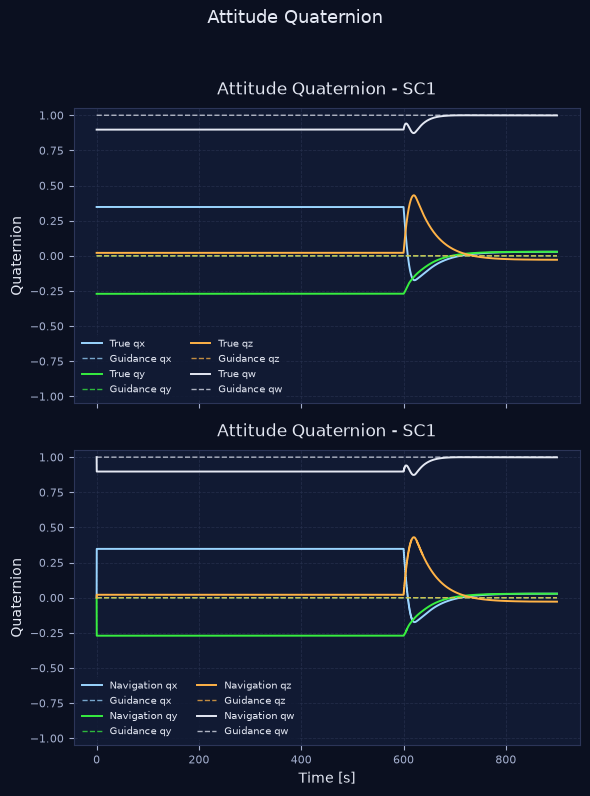

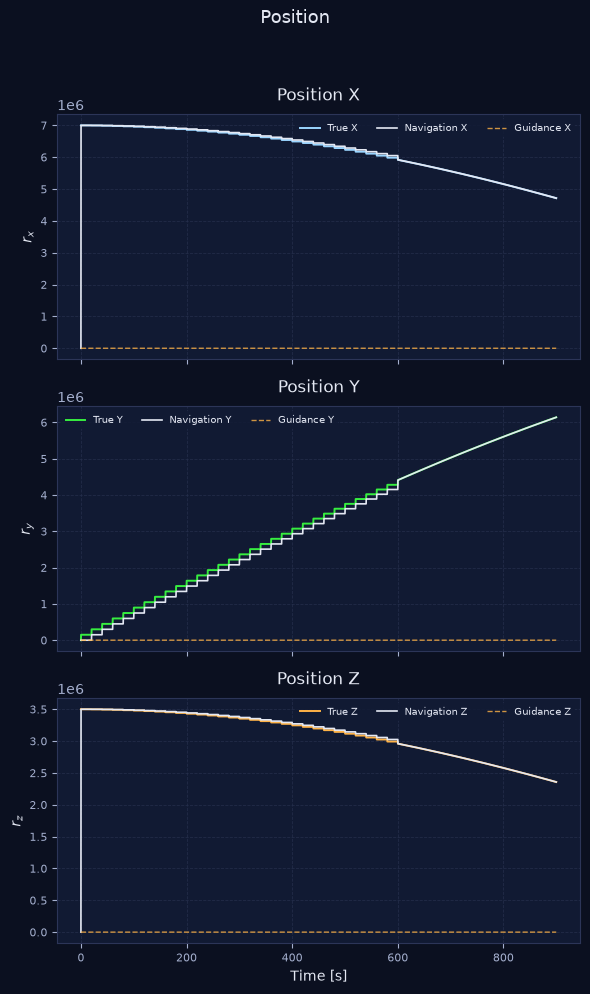

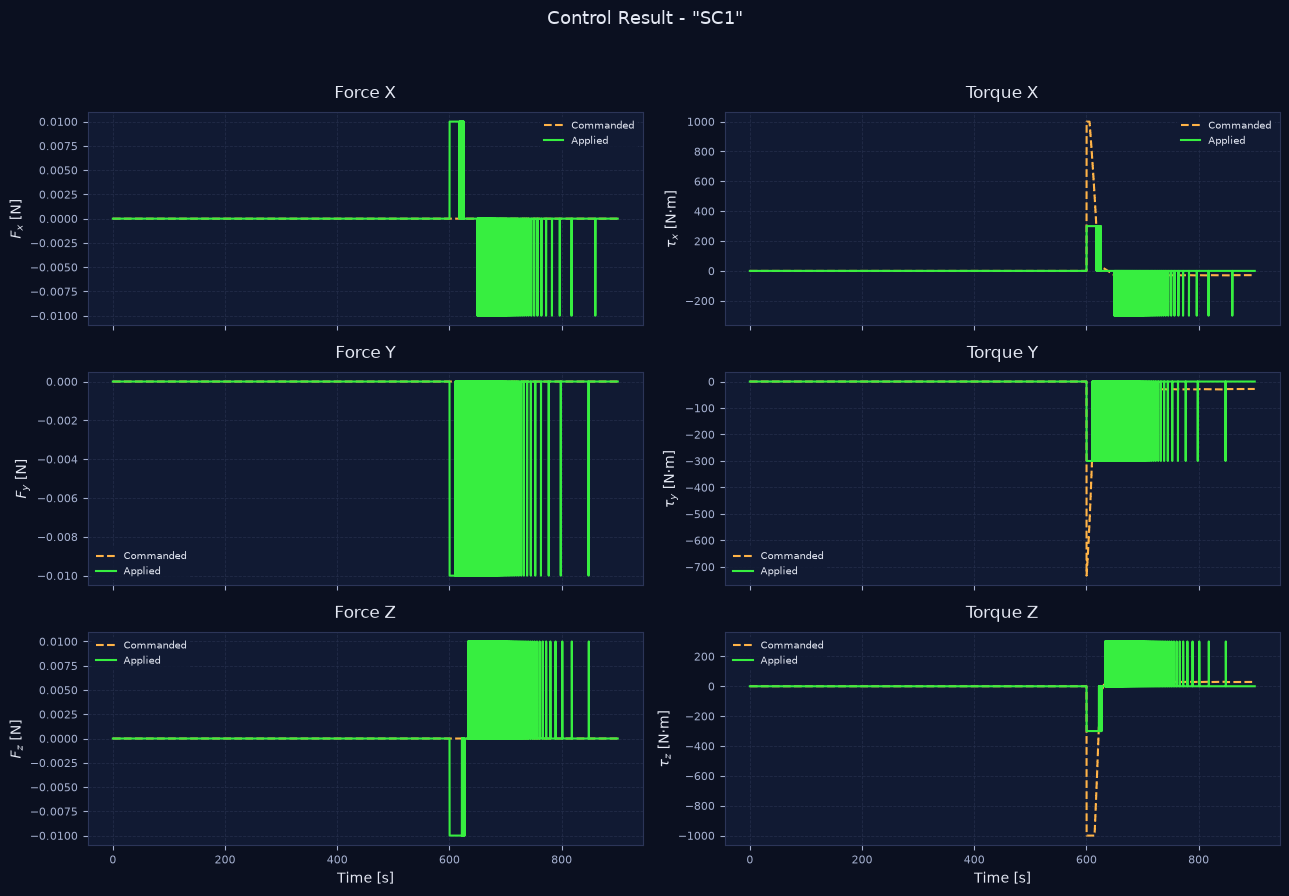

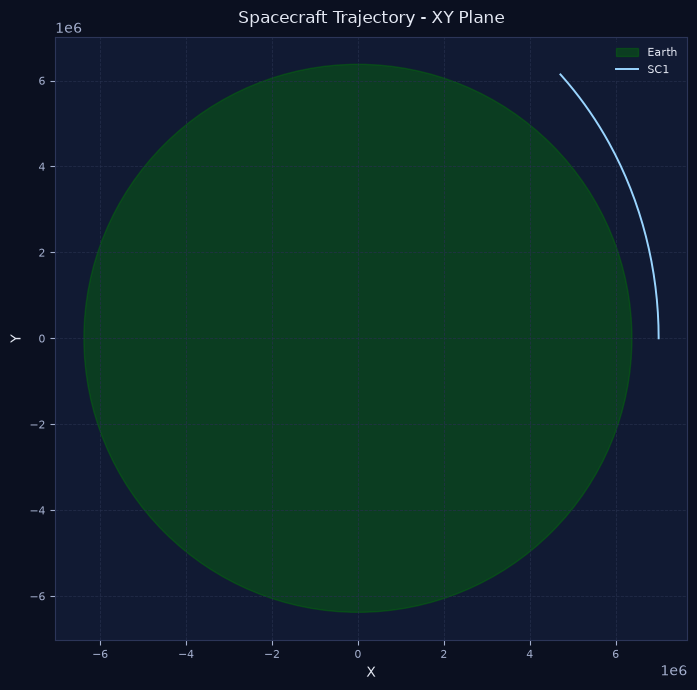

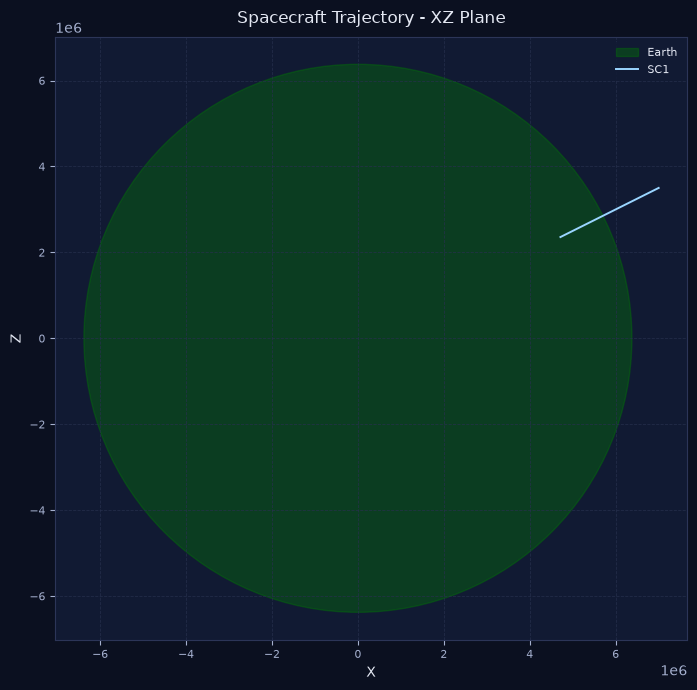

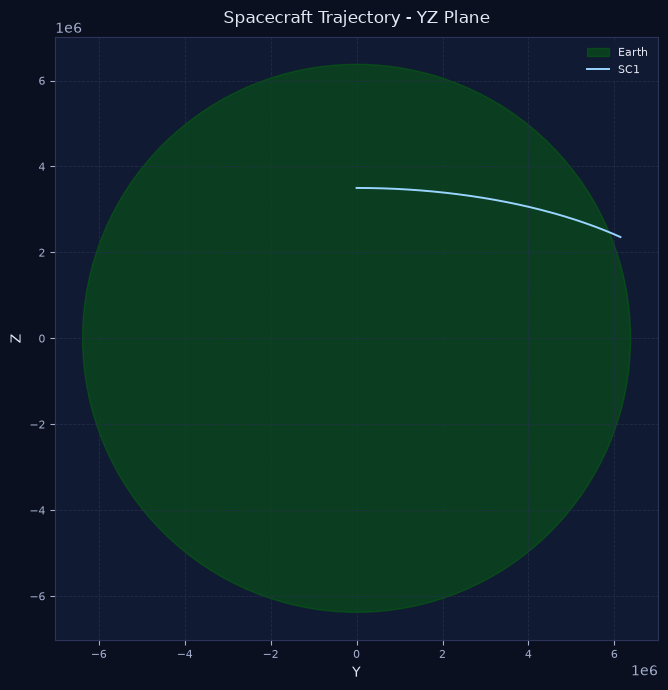

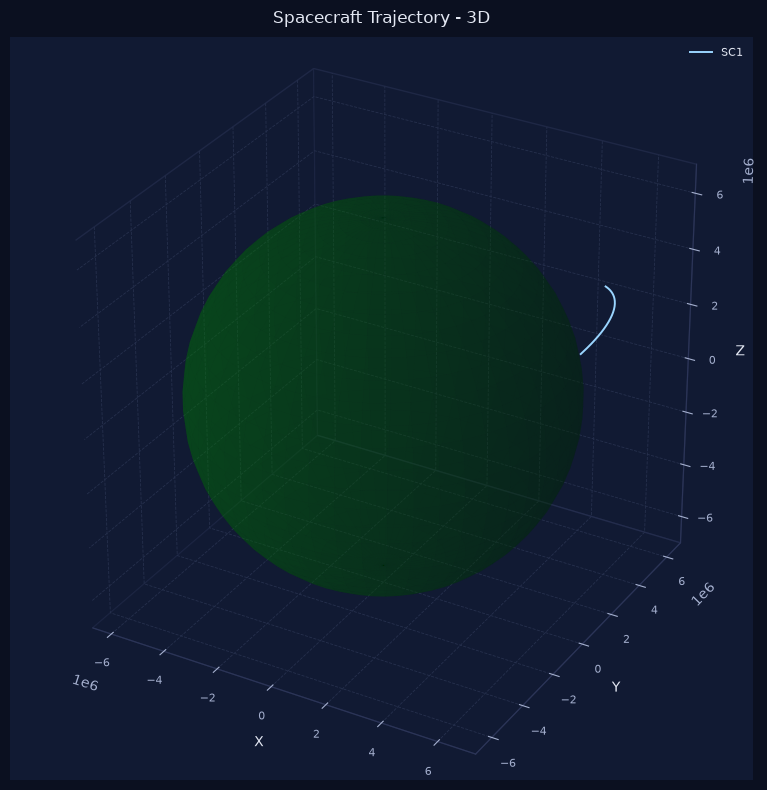

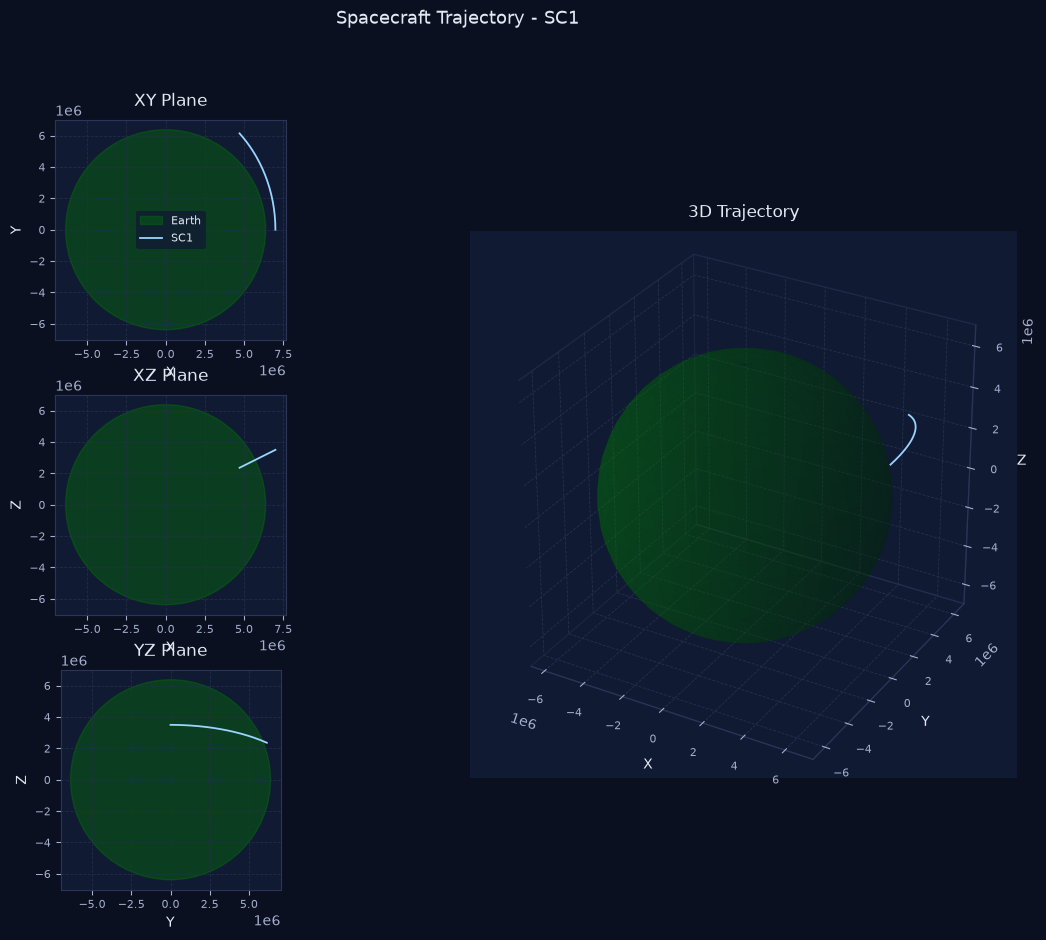

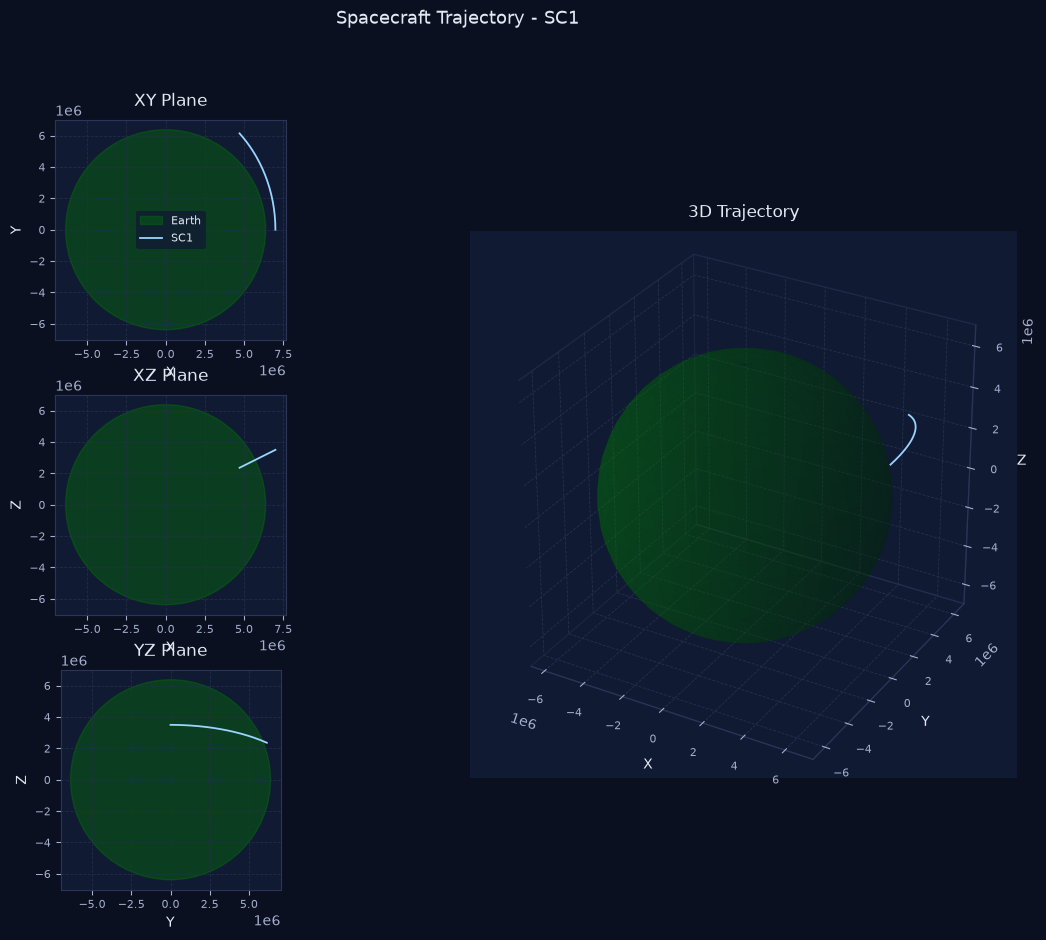

In [63]:
from py.modules.visualization.state_variables import plot_attitude_quaternions, plot_position

plot_attitude_quaternions(["SC1"], result, show=True)
plot_position(["SC1"], result, show=True)


from py.modules.visualization.gnc import plot_control_result
plot_control_result("SC1", result)

from py.modules.visualization.trajectories import *

plot_trajectory_xy(["SC1"], result, show=True, body="Earth",)
plot_trajectory_xz(["SC1"], result, show=True, body="Earth",)
plot_trajectory_yz(["SC1"], result, show=True, body="Earth",)
plot_trajectory_3d(["SC1"], result, show=True, body="Earth",)
plot_trajectory(["SC1"], result, show=True, body="Earth",)